# Detection v1 — run & evaluate

Thin runner for the full cascade (L1 Stage1 → L2 Consolidator → L3 Classifier). Fits on the 90-recording
train split, checks the L3 window centring on the train split, evaluates on the 10 held-out test
recordings, saves the model. All logic lives in `src/` (`detect_config`, `detect_data`, `detection`,
`detect_metrics`); this notebook just wires it together.

**~5 min to run** (the L3 registration fit dominates; L1+L2 over all 90 recordings takes ~8 s).
Numbers are indicative — only ~5 test IEDs.

In [1]:
%load_ext autoreload
%autoreload 2
# ^ re-imports src/ on every cell run. Without it, editing detect_config.py or detect_metrics.py has no
#   effect until the kernel is restarted — silently, so a changed setting looks like it "did nothing".

import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import load_dataset, stratified_split
from detection import Config, DetectionPipeline
import detect_metrics as M

cfg = Config()
man = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
train_df, test_df = stratified_split(man, n_test=cfg.n_test, seed=cfg.split_seed)   # 90 / 10, deterministic
REC = Path('..') / 'Kural_Dataset' / 'Recordings'
train = load_dataset(train_df, REC, cfg)   # pass cfg: preprocessing must match what the model is
test  = load_dataset(test_df, REC, cfg)    # built with, or data and model silently diverge
print(f"{len(train)} train / {len(test)} test  ({sum(r['epi'] for r in test)} test IEDs)")
print(f"preprocess: {cfg.sfreq:.0f} Hz  bandpass={cfg.bandpass}  reference={cfg.reference!r}  "
      f"bad soft/hard={cfg.bad_soft_factor}/{cfg.bad_hard_factor}x cap={cfg.max_interpolate}")
print(f"model: grouping={cfg.grouping!r} corr={cfg.corr_threshold} centre_on={cfg.centre_on!r} "
      f"n_basis={cfg.n_basis} k={cfg.n_components} registration={cfg.registration!r} "
      f"polarity={cfg.polarity_feature}")
bad = [(r["fid"], r["bad_soft"], r["bad_hard"]) for r in train + test if r["bad_soft"] or r["bad_hard"]]
print(f"bad channels flagged in {len(bad)} of {len(train) + len(test)} recordings: {bad}")

pipe = DetectionPipeline(cfg).fit(train)     # trains L3 on consolidated TRAIN candidates only
print('fit:', pipe.train_stats_)
pipe.save('../detect_model.joblib')          # shippable model (Config + fitted classifier)

90 train / 10 test  (5 test IEDs)
preprocess: 250 Hz  bandpass=(0.5, 45.0)  reference='average'  bad soft/hard=3.0/10.0x cap=2
model: grouping='components' corr=0.7 centre_on='amplitude' n_basis=70 k=24 registration='elastic' polarity=True
bad channels flagged in 1 of 100 recordings: [('S49', [16], [])]
fit: {'windows': 4157, 'positives': 60}


## Window centring check (TRAIN only)

`event_window` re-centres each event before cutting the 2 s window the classifier sees. That choice is
potentially load-bearing: **Fisher-Rao registration is alignment-sensitive**, so if the re-centring lands
on the wrong extremum — an after-going slow wave, a baseline drift, the biphasic down-stroke — every FDA
feature is computed on a shifted curve, and L3's AUC would be depressed for a reason that has nothing to
do with the model. This section tests that.

`cfg.centre_on` picks the rule:
- `'amplitude'` — max |deviation from the local median| of the smoothed signal. Matches the annotation
  convention (marker at the spike peak) and how the classification-phase windows were cut, but the
  *largest* deflection near a spike is often the slow after-going component, not the spike.
- `'sharpness'` — max of the L1 statistic (|SG 2nd deriv| / MAD). Curvature peaks at the apex of a sharp
  transient, so a slow wave can't win.

Offsets below are measured against the **neurologist marker** (0 ms = the window centre sits exactly on
the annotated spike peak), over the 90-train only.

In [2]:
import numpy as np, matplotlib.pyplot as plt
from dataclasses import replace

off = {}                                  # centring rule -> (positive windows, offsets ms, recording ids)
for mode in ('amplitude', 'sharpness'):
    off[mode] = M.centring_offsets(DetectionPipeline(replace(cfg, centre_on=mode)), train)
    a = np.abs(off[mode][1])
    print(f"centre_on={mode:<10s} n={len(a):3d}   |offset| median {np.median(a):3.0f} ms  "
          f"p90 {np.percentile(a, 90):3.0f} ms  max {a.max():3.0f} ms   >100 ms: {(a > 100).mean():.0%}")

centre_on=amplitude  n= 60   |offset| median  28 ms  p90 152 ms  max 184 ms   >100 ms: 22%
centre_on=sharpness  n= 60   |offset| median  16 ms  p90  68 ms  max 100 ms   >100 ms: 0%


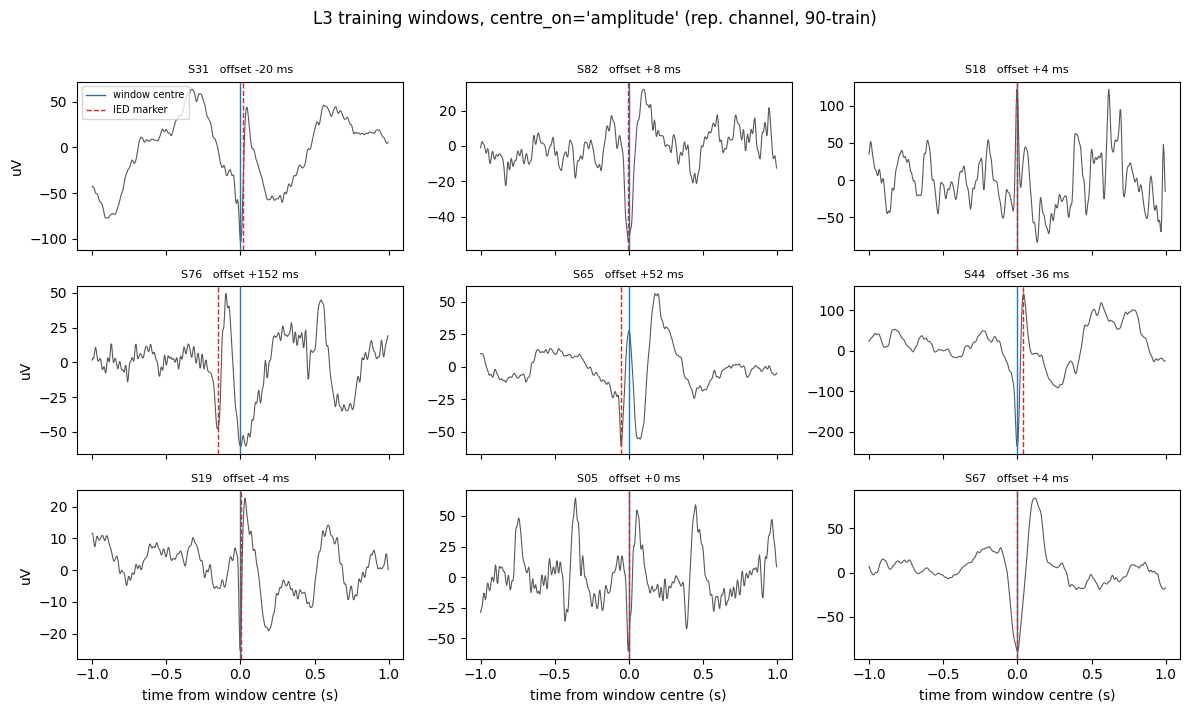

In [3]:
# eyeball 9 IED windows (one per recording) under the configured rule: centre should sit on the marker
W, offs, fids = off[cfg.centre_on]
seen, pick = set(), []
for i, f in enumerate(fids):
    if f not in seen:
        seen.add(f); pick.append(i)
t = (np.arange(W.shape[1]) - W.shape[1] // 2) / cfg.sfreq

fig, axs = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
for ax, i in zip(axs.ravel(), pick[:9]):
    ax.plot(t, W[i], lw=0.8, color='0.35')
    ax.axvline(0, color='C0', lw=1.0, label='window centre')
    ax.axvline(-offs[i] / 1000, color='C3', ls='--', lw=1.0, label='IED marker')
    ax.set_title(f"{fids[i]}   offset {offs[i]:+.0f} ms", fontsize=8)
axs[0, 0].legend(fontsize=7, loc='upper left')
for ax in axs[-1]:
    ax.set_xlabel('time from window centre (s)')
for ax in axs[:, 0]:
    ax.set_ylabel('uV')
plt.suptitle(f"L3 training windows, centre_on='{cfg.centre_on}' (rep. channel, 90-train)", y=1.01)
plt.tight_layout()
plt.savefig(f'../figures/detection_window_centring_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

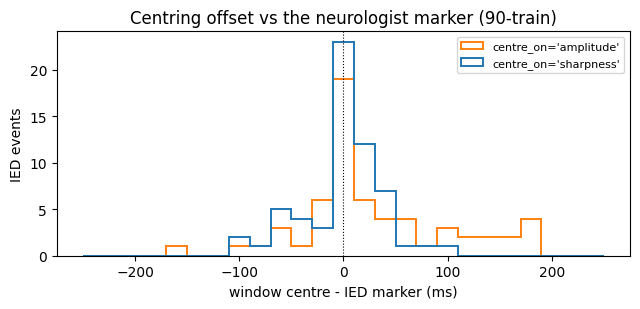

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
for mode, c in (('amplitude', 'C1'), ('sharpness', 'C0')):
    ax.hist(off[mode][1], bins=np.arange(-250, 251, 20), histtype='step', lw=1.4, color=c,
            label=f"centre_on='{mode}'")
ax.axvline(0, color='k', ls=':', lw=0.8)
ax.set_xlabel('window centre - IED marker (ms)'); ax.set_ylabel('IED events')
ax.set_title('Centring offset vs the neurologist marker (90-train)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/detection_centring_offsets.png', dpi=800, bbox_inches='tight')
plt.show()

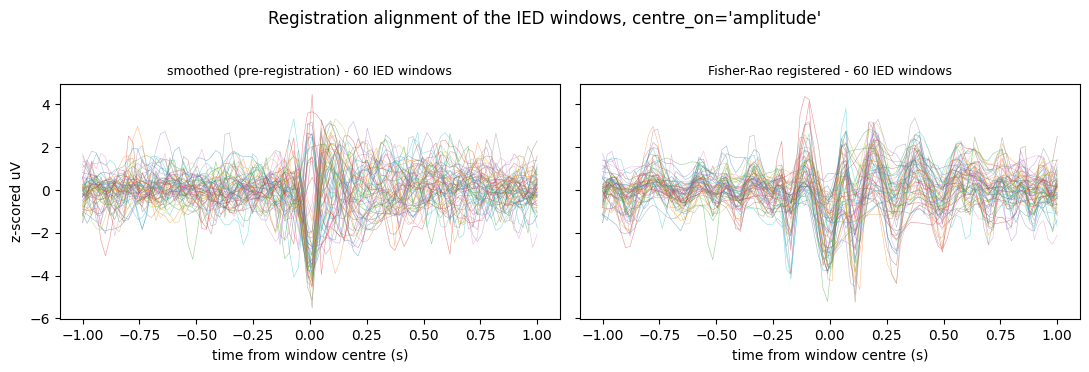

In [5]:
# do the positive windows stack once registered? (the curves the LR actually sees)
sm, al = pipe.classifier.aligned_curves(off[cfg.centre_on][0])
z = lambda A: (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-12)
tt = np.linspace(-cfg.classifier_halfwin_s, cfg.classifier_halfwin_s, sm.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, A, ttl in ((axs[0], sm, 'smoothed (pre-registration)'), (axs[1], al, 'Fisher-Rao registered')):
    ax.plot(tt, z(A).T, lw=0.4, alpha=0.5)
    ax.set_title(f"{ttl} - {len(A)} IED windows", fontsize=9)
    ax.set_xlabel('time from window centre (s)')
axs[0].set_ylabel('z-scored uV')
plt.suptitle(f"Registration alignment of the IED windows, centre_on='{cfg.centre_on}'", y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/detection_registration_alignment_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

In [6]:
print('=== TEST (10 recordings) ===')
E_te, S_te, Y_te, G_te = M.report(pipe, test)   # one L1+L2+L3 pass, reused by the plots below

=== TEST (10 recordings) ===
  L1 IED recall            : 1.00
  L2 consolidation recall  : 1.00
  L2 events                : 224/min, 1.00 per IED, 4.96 channels each
  L3 ROC-AUC / PR-AUC      : 0.874 / 0.143   (PR chance = 0.011)
  localisation error (ms)  : 4
  centre baseline          : sens 0.40, 4.0 FP/min  (to beat)
  FROC — best sensitivity at FP/min budget:
    <=   1 FP/min : sens 0.20
    <=   5 FP/min : sens 0.20
    <=  10 FP/min : sens 0.20
    <=  25 FP/min : sens 0.60
    <=  50 FP/min : sens 0.80
    <= 100 FP/min : sens 1.00
  operating point @ <= 10 FP/min (score >= 1.00):
    hits 1/5   misses 4   false positives 1 (0.5/min)


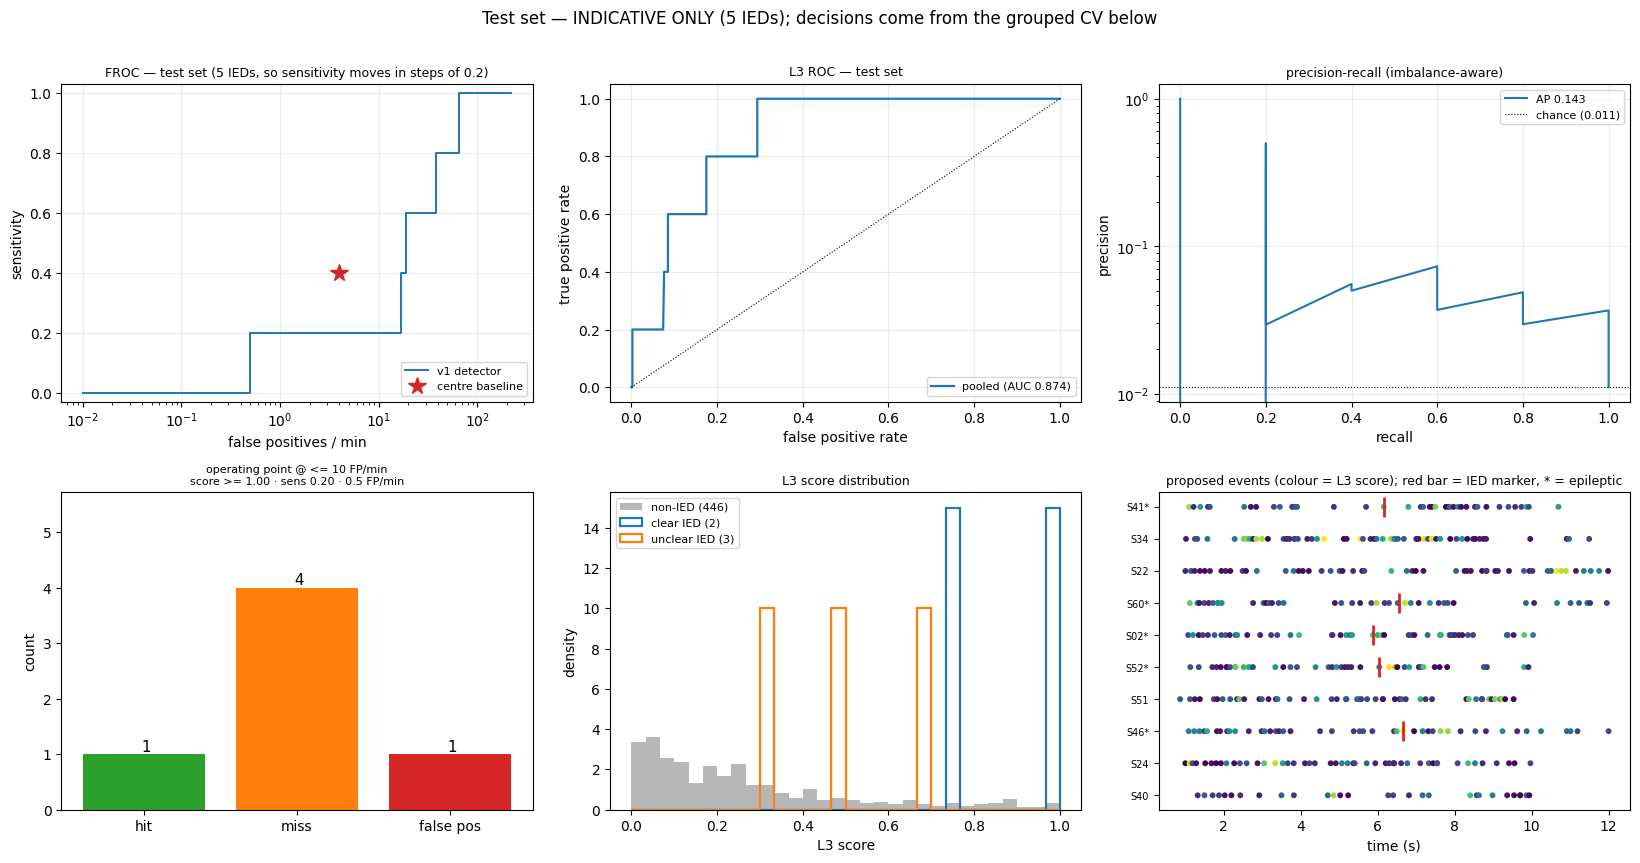

In [22]:
import detect_plots as P

pts_te = M.froc_points(test, E_te, G_te, S_te, cfg)
cm_te = M.detection_counts(test, E_te, G_te, S_te, cfg,
                           M.threshold_at(pts_te, M.FP_BUDGET))

fig, axs = plt.subplots(2, 3, figsize=(16.5, 8.5))
n_ied = sum(r['epi'] for r in test)
P.froc(axs[0, 0], pts_te, label='v1 detector', baseline=M.centre_baseline(test, cfg))
axs[0, 0].set_title(f'FROC — test set ({n_ied} IEDs, so sensitivity moves in steps '
                    f'of {1 / n_ied:.1f})', fontsize=9)
P.roc(axs[0, 1], Y_te, S_te)
axs[0, 1].set_title('L3 ROC — test set', fontsize=9)
P.pr(axs[0, 2], Y_te, S_te)
axs[0, 2].set_title('precision-recall (imbalance-aware)', fontsize=9)
P.counts(axs[1, 0], cm_te, f'operating point @ <= {M.FP_BUDGET:.0f} FP/min')
P.score_hist(axs[1, 1], Y_te, S_te, G_te, test)
axs[1, 1].set_title('L3 score distribution', fontsize=9)
P.timeline(axs[1, 2], test, E_te, G_te, S_te, cfg)
plt.suptitle('Test set — INDICATIVE ONLY (5 IEDs); decisions come from the grouped CV below', y=1.01)
plt.tight_layout()
plt.savefig('../figures/detection_test_metrics.png', dpi=800, bbox_inches='tight')
plt.show()

## Grouped cross-validation on the 90-train (run on demand)

**This is where every tuning decision should be read from**, not from the test set above. The test split
holds ~5 IEDs, so its AUC swings ±0.05 between configurations whose FROC is identical — measured, see
report.md. Here the folds are **grouped by recording**, so the several events one IED spawns never land
on both sides of a split, and pooling the out-of-fold scores gives a FROC over all ~49 train IEDs
instead of 5.

**Independent cell:** nothing else in this notebook depends on it. Set `RUN_GROUPED_CV = True` to run it
(~15–20 min: one full L3 fit per fold).

grouped-CV AUC 0.865  95% CI [0.797, 0.929]   PR-AUC 0.170
per fold        0.840 · 0.865 · 0.817 · 0.919 · 0.894
windows 4157, positives 60, localisation median 12 ms over 48 IEDs
cross-validated FROC — best sensitivity at FP/min budget:
    <=   1 FP/min : sens 0.14
    <=   5 FP/min : sens 0.51
    <=  10 FP/min : sens 0.67
    <=  25 FP/min : sens 0.82
    <=  50 FP/min : sens 0.92
    <= 100 FP/min : sens 0.94
operating point @ <= 10 FP/min (score >= 0.80): hits 33/49  misses 16  false positives 181 (9.5/min)


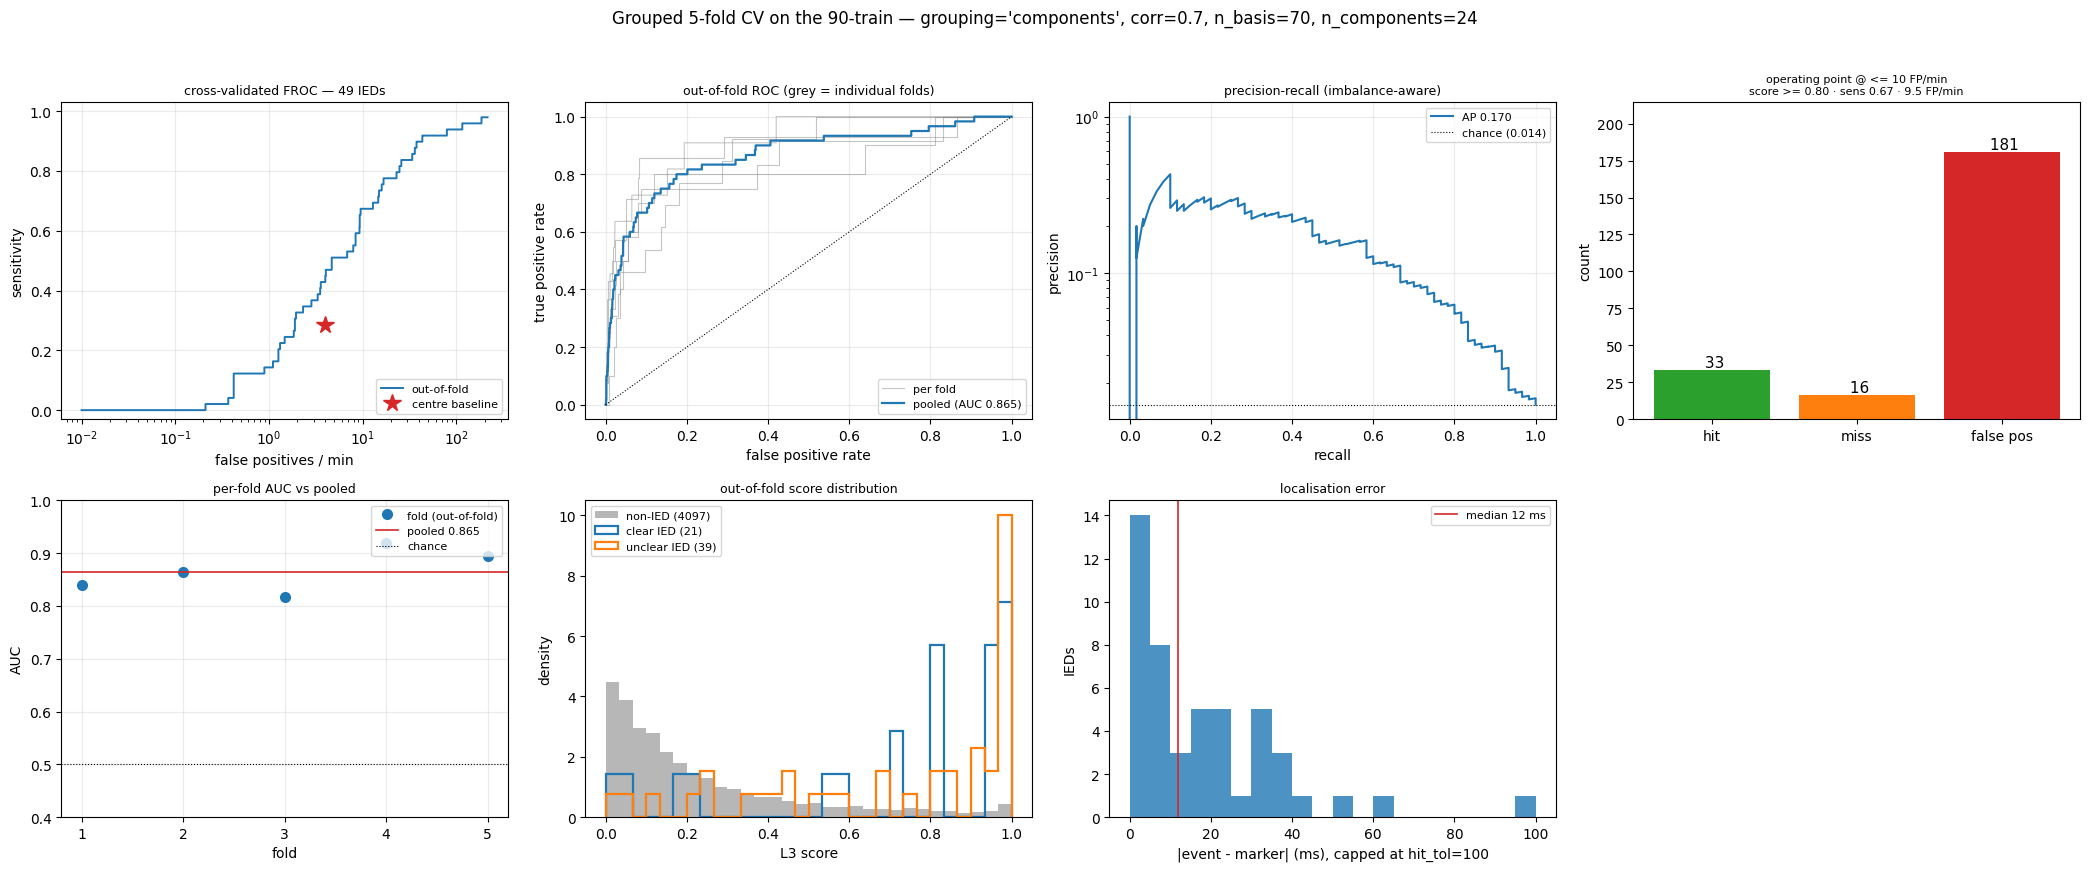

In [8]:
RUN_GROUPED_CV = True         # ~15-20 min (one L3 fit per fold). Nothing below depends on this cell.

if RUN_GROUPED_CV:
    cv = M.grouped_cv(pipe, train)                       # out-of-fold scores over every train candidate
    lo, hi = M.bootstrap_auc_ci(cv['Y'], cv['G'], cv['scores'])
    pts = M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg)
    errs = M.localisation_errors(train, cv['events'], cv['G'], cv['scores'], cfg)
    cm = M.detection_counts(train, cv['events'], cv['G'], cv['scores'], cfg,
                            M.threshold_at(pts, M.FP_BUDGET))
    print(f"grouped-CV AUC {cv['auc']:.3f}  95% CI [{lo:.3f}, {hi:.3f}]   PR-AUC {cv['ap']:.3f}")
    print(f"per fold        {' · '.join(f'{f:.3f}' for f in cv['folds'])}")
    print(f"windows {len(cv['Y'])}, positives {cv['Y'].sum()}, "
          f"localisation median {np.median(errs):.0f} ms over {len(errs)} IEDs")
    print('cross-validated FROC — best sensitivity at FP/min budget:')
    for fp, sens in M.froc_summary(pts).items():
        print(f'    <= {fp:>3} FP/min : sens {sens:.2f}')
    print(f"operating point @ <= {M.FP_BUDGET:.0f} FP/min "
          f"(score >= {cm['threshold']:.2f}): hits {cm['hit']}/{cm['hit'] + cm['miss']}  "
          f"misses {cm['miss']}  false positives {cm['fp']} ({cm['fp_per_min']:.1f}/min)")

    fig, axs = plt.subplots(2, 4, figsize=(21, 8.5))
    P.froc(axs[0, 0], pts, label='out-of-fold', baseline=M.centre_baseline(train, cfg))
    axs[0, 0].set_title(f"cross-validated FROC — {sum(r['epi'] for r in train)} IEDs", fontsize=9)
    P.roc(axs[0, 1], cv['Y'], cv['scores'],
          folds=[(cv['Y'][cv['fold'] == k], cv['scores'][cv['fold'] == k])
                 for k in range(len(cv['folds']))])
    axs[0, 1].set_title('out-of-fold ROC (grey = individual folds)', fontsize=9)
    P.pr(axs[0, 2], cv['Y'], cv['scores'])
    axs[0, 2].set_title('precision-recall (imbalance-aware)', fontsize=9)
    P.counts(axs[0, 3], cm, f'operating point @ <= {M.FP_BUDGET:.0f} FP/min')
    P.fold_aucs(axs[1, 0], cv['folds'], cv['auc'])
    axs[1, 0].set_title('per-fold AUC vs pooled', fontsize=9)
    P.score_hist(axs[1, 1], cv['Y'], cv['scores'], cv['G'], train)
    axs[1, 1].set_title('out-of-fold score distribution', fontsize=9)
    P.loc_error(axs[1, 2], errs, cfg)
    axs[1, 2].set_title('localisation error', fontsize=9)
    axs[1, 3].axis('off')
    plt.suptitle(f"Grouped 5-fold CV on the 90-train — grouping='{cfg.grouping}', "
                 f"corr={cfg.corr_threshold}, n_basis={cfg.n_basis}, n_components={cfg.n_components}",
                 y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/detection_grouped_cv.png', dpi=800, bbox_inches='tight')
    plt.show()

In [9]:
# n_components sweep. Registration is fitted ONCE per fold and reused, so every k after that is ~free.
n_components_sweep = False

if n_components_sweep:
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    KS = [2, 4, 6, 8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    scores = {k: np.zeros(len(Y)) for k in KS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=max(KS)).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        for k in KS:
            sc = StandardScaler().fit(P_tr[:, :k])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(P_tr[:, :k]), Y[tr])
            scores[k][te] = lr.predict_proba(sc.transform(P_te[:, :k]))[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"{'k':>4} {'AUC':>7} {'95% CI':>18} {'sens@10':>8} {'sens@25':>8} {'sens@50':>8}")
    for k in KS:
        lo, hi = M.bootstrap_auc_ci(Y, G, scores[k], n_boot=500)
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"{k:>4} {roc_auc_score(Y, scores[k]):>7.3f}   [{lo:.3f}, {hi:.3f}]   "
            f"{fs[10]:>8.2f} {fs[25]:>8.2f} {fs[50]:>8.2f}")


In [10]:
if n_components_sweep:
    import joblib; joblib.dump({'KS': KS, 'scores': scores, 'Y': Y, 'G': G}, '/tmp/sweep_ncomp.joblib')
    for k in (4, 12, 16, 24, 32):
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"k={k:>3}  " + "  ".join(f"@{b}:{fs[b]:.2f}" for b in (1, 5, 10, 25, 50, 100)))
    print("centre baseline:", M.centre_baseline(train, cfg))


In [11]:
n_basis_sweep = False

if n_basis_sweep:

    from dataclasses import replace
    import joblib
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier
    BASES, KS = [30, 50, 70, 100], [8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)      # L1/L2 are independent of n_basis
    sweep = {}
    print(f"{'n_basis':>7} {'k':>4} {'AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}")
    for b in BASES:
        c = replace(cfg, n_basis=b)
        clf, ks = Classifier(c), [k for k in KS if k <= b - 2]   # can't keep more components than basis fns
        sc = {k: np.zeros(len(Y)) for k in ks}
        for tr, te in GroupKFold(n_splits=5).split(W, Y, G):
            fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
            reg = FisherRaoElasticRegistration(penalty=c.penalty).fit(fds_tr)
            al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
            fpca = FPCA(n_components=max(ks)).fit(al_tr)
            P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
            for k in ks:
                s = StandardScaler().fit(P_tr[:, :k])
                lr = LogisticRegression(C=c.lr_C, max_iter=1000, class_weight='balanced')
                lr.fit(s.transform(P_tr[:, :k]), Y[tr])
                sc[k][te] = lr.predict_proba(s.transform(P_te[:, :k]))[:, 1]
        for k in ks:
            fs = M.froc_summary(M.froc_points(train, E, G, sc[k], cfg), fp_targets=(5, 10, 25))
            print(f"{b:>7} {k:>4} {roc_auc_score(Y, sc[k]):>7.3f} {fs[5]:>6.2f} {fs[10]:>6.2f} "
                f"{fs[25]:>6.2f}", flush=True)
        sweep[b] = sc
    joblib.dump({'sweep': sweep, 'Y': Y, 'G': G}, '/tmp/sweep_basis.joblib')


In [12]:
# hard-negative-mining sweep. Mining only changes which rows the LR trains on, and it sits AFTER
# registration + FPCA, so every ratio shares one CV run — the same trick as the n_components sweep.
hard_neg_sweep = False

if hard_neg_sweep:
    from dataclasses import replace
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    RATIOS = [0, 2, 5, 10, 20, 50]        # hardest negatives kept per positive; 0 = keep all (current)
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    sc = {r: np.zeros(len(Y)) for r in RATIOS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        fpca = FPCA(n_components=cfg.n_components).fit(reg.transform(fds_tr))
        P_tr, P_te = fpca.transform(reg.transform(fds_tr)), fpca.transform(reg.transform(fds_te))
        s = StandardScaler().fit(P_tr)
        Z_tr, Z_te = s.transform(P_tr), s.transform(P_te)
        lr0 = clf._fit_lr(Z_tr, Y[tr])                      # first pass: all negatives
        for r in RATIOS:
            if r == 0:
                lr = lr0
            else:
                c = Classifier(replace(cfg, hard_neg_ratio=r))
                c._lr = lr0                                  # mine against the first-pass ranking
                lr = c._fit_lr(*c._mine(Z_tr, Y[tr]))
            sc[r][te] = lr.predict_proba(Z_te)[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"\n{'ratio':>6} {'ROC-AUC':>8} {'PR-AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}   "
          f"hits/misses/FP @ <= {M.FP_BUDGET:.0f} FP/min")
    for r in RATIOS:
        pts = M.froc_points(train, E, G, sc[r], cfg)
        fs = M.froc_summary(pts, fp_targets=(5, 10, 25))
        c = M.detection_counts(train, E, G, sc[r], cfg, M.threshold_at(pts, M.FP_BUDGET))
        print(f"{r:>6} {roc_auc_score(Y, sc[r]):>8.3f} {average_precision_score(Y, sc[r]):>7.3f} "
              f"{fs[5]:>6.2f} {fs[10]:>6.2f} {fs[25]:>6.2f}   "
              f"{c['hit']:>3} / {c['miss']:>3} / {c['fp']:>4}")
    print(f"(PR-AUC chance = {Y.mean():.3f};  centre baseline "
          f"{M.centre_baseline(train, cfg)[0]:.2f} @ {M.centre_baseline(train, cfg)[1]:.1f} FP/min)")


In [13]:
# paired bootstrap of the mining gain — needs `sc`/`Y`/`G` from the sweep cell above
if hard_neg_sweep:
    from sklearn.metrics import average_precision_score
    rng, groups, d = np.random.default_rng(0), np.unique(G), []
    for _ in range(2000):
        idx = np.concatenate([np.where(G == k)[0] for k in rng.choice(groups, len(groups), replace=True)])
        if len(set(Y[idx].tolist())) > 1:
            d.append(average_precision_score(Y[idx], sc[20][idx])
                     - average_precision_score(Y[idx], sc[0][idx]))
    d = np.array(d)
    print(f"PR-AUC(ratio 20) - PR-AUC(all): {d.mean():+.3f}  "
          f"95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]  P(>0)={np.mean(d > 0):.2f}")


## Error analysis — where the detector fails, and why

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Both failure modes matter, and the misses are the more informative half. The interesting property is that
**nearly all misses are L3 ranking failures** — L1 and L2 recall are high enough that almost every IED
already has a near-marker event in the candidate pool, so the front end did its job and L3 scored the
event too low. That gives clean attribution: one place to look, not three. (The exception is any IED whose
event is captured but *timestamped* outside the hit tolerance — see deferred item I in report.md §8.)

The analysis runs in three phases, cheapest and most decision-changing first.

**Phase 1 (below) — bookkeeping on the out-of-fold scores. No refitting, seconds to run.**
- **Q1 · hits and misses by certainty.** If the detector finds most `clear_positive` IEDs and fails on
  `unclear_positive` ones, "59% at 10 FP/min" becomes something like "85% of clear, 40% of unclear" — a
  more honest headline, with the failures on cases the neurologists themselves hedged about.
- **Q2 · how badly are the misses missed?** For each missed IED, how many extra false positives you would
  have to accept to catch it. A few just below threshold means small gains recover several IEDs; a long
  tail means those IEDs are a different population and no threshold change reaches them.
- **Q3 · are the false positives concentrated?** If a handful of noisy recordings generate most of them,
  the fix is per-recording amplitude normalisation and has nothing to do with spatial features. If they
  are spread evenly, it is a genuine morphology problem and L4 is the right tool. Different diagnoses,
  completely different work.
- **Q4 · do FPs come from negative or from epileptic recordings?** Both are true false positives (epileptic
  recordings are verified single-IED, so all non-marker EEG is IED-free), but a skew toward epileptic
  recordings points at something recording-level rather than a generic mimic problem.

**Phase 2 — qualitative.** Plot the top false positives and the missed IEDs and classify them by eye:
muscle, eye blink, sharp alpha, electrode pop, or a genuine-looking discharge that was never marked. That
last category is the important one — if the top FPs look like real IEDs, the ceiling is the label set
rather than the model, and that is a finding about the data.

**Phase 3 — the spatial-feature separation test.** Compute candidate L4 features (largest spatially
connected cluster, polarity split across the field, amplitude-gradient smoothness) for exactly the hits
and false positives at the operating point, and measure univariate separation. **Kill criterion, stated in advance:** if no
single feature reaches a univariate AUC of about 0.65 on that comparison, L4 cannot rescue these false
positives, and spatial features get reported as tested-and-rejected alongside centring and hard-negative
mining.

operating point: score >= 0.800  (<= 10 FP/min)

Q1  hits / misses by certainty
      clear_positive     13 found /  7 missed   (65%)
      unclear_positive   20 found /  9 missed   (69%)

Q2  16 missed IEDs — extra FPs needed to catch each (cheapest first)
      S42    unclear_positive   best score 0.743   +245 FPs
      S08    clear_positive     best score 0.714   +279 FPs
      S09    clear_positive     best score 0.711   +284 FPs
      S86    unclear_positive   best score 0.691   +304 FPs
      S27    unclear_positive   best score 0.679   +318 FPs
      S19    clear_positive     best score 0.584   +437 FPs
      S44    clear_positive     best score 0.558   +470 FPs
      S56    unclear_positive   best score 0.542   +492 FPs
      median +567 FPs;  0 of 16 cost <= 50 FPs, 8 cost > 500 (effectively unreachable)

Q3  181 false positives over 67 of 90 recordings
      worst 9 recordings hold 35% of them (worst single recording: 12)

Q4  where the false positives come from
      epilept

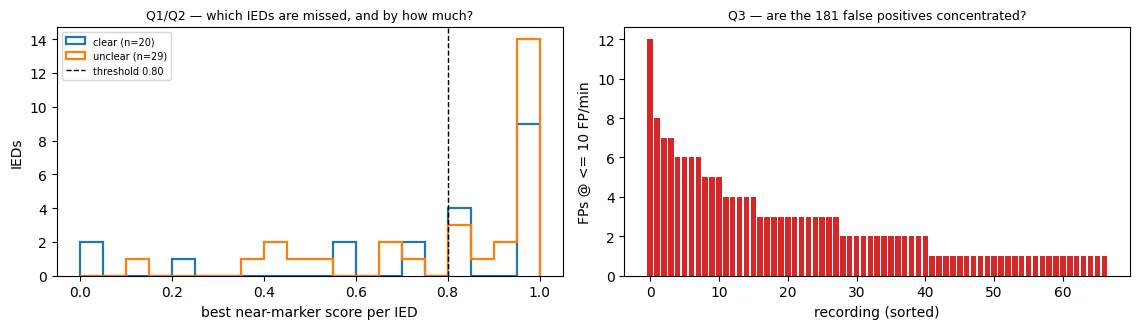

In [14]:
# Phase 1 — error analysis on the out-of-fold CV scores. No refitting: pure bookkeeping.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    tol = cfg.samp(cfg.hit_tol_ms)
    pts = M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg)
    thr = M.threshold_at(pts, M.FP_BUDGET)
    epi = [g for g, r in enumerate(train) if r['epi']]

    best, fp_per_rec, nonhit = {}, {}, []          # best near-marker score / FPs per rec / all non-hit scores
    for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
        r = train[g]
        if r['epi'] and abs(e['time'] - r['mk']) <= tol:
            best[g] = max(best.get(g, 0.0), s)
        else:
            nonhit.append(s)
            if s >= thr:
                fp_per_rec[g] = fp_per_rec.get(g, 0) + 1
    nonhit = np.array(nonhit)
    print(f"operating point: score >= {thr:.3f}  (<= {M.FP_BUDGET:.0f} FP/min)\n")

    print('Q1  hits / misses by certainty')
    for c in ('clear_positive', 'unclear_positive'):
        gs = [g for g in epi if train[g]['cert'] == c]
        h = sum(best.get(g, 0.0) >= thr for g in gs)
        print(f"      {c:<18} {h:>2} found / {len(gs) - h:>2} missed   ({h / max(len(gs), 1):.0%})")

    missed = [g for g in epi if best.get(g, 0.0) < thr]
    cost = {g: int((nonhit > best.get(g, 0.0)).sum()) for g in missed}
    print(f"\nQ2  {len(missed)} missed IEDs — extra FPs needed to catch each (cheapest first)")
    for g in sorted(missed, key=lambda g: cost[g])[:8]:
        print(f"      {train[g]['fid']:<6} {train[g]['cert']:<18} best score {best.get(g, 0.0):.3f}"
              f"   +{cost[g]} FPs")
    if missed:
        cs = np.array(sorted(cost.values()))
        print(f"      median +{int(np.median(cs))} FPs;  {(cs <= 50).sum()} of {len(cs)} cost <= 50 FPs, "
              f"{(cs > 500).sum()} cost > 500 (effectively unreachable)")

    counts = np.array(sorted(fp_per_rec.values(), reverse=True))
    tot = int(counts.sum())
    print(f"\nQ3  {tot} false positives over {len(fp_per_rec)} of {len(train)} recordings")
    if tot:
        k = max(1, len(train) // 10)
        print(f"      worst {k} recordings hold {counts[:k].sum() / tot:.0%} of them "
              f"(worst single recording: {counts[0]})")

    print('\nQ4  where the false positives come from')
    for lbl, sel in (('epileptic', True), ('non-epileptic', False)):
        gs = [g for g, r in enumerate(train) if r['epi'] == sel]
        n = sum(fp_per_rec.get(g, 0) for g in gs)
        mins = sum(train[g]['dur'] for g in gs) / 60.0
        print(f"      {lbl:<14} {n:>4} FPs over {len(gs):>2} recordings / {mins:.1f} min "
              f"= {n / mins:>5.1f} FP/min")

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.4))
    for c, col in (('clear_positive', 'C0'), ('unclear_positive', 'C1')):
        v = [best.get(g, 0.0) for g in epi if train[g]['cert'] == c]
        axs[0].hist(v, bins=np.linspace(0, 1, 21), histtype='step', lw=1.6, color=col,
                    label=f"{c.split('_')[0]} (n={len(v)})")
    axs[0].axvline(thr, color='k', ls='--', lw=1.0, label=f'threshold {thr:.2f}')
    axs[0].set_xlabel('best near-marker score per IED'); axs[0].set_ylabel('IEDs')
    axs[0].set_title('Q1/Q2 — which IEDs are missed, and by how much?', fontsize=9)
    axs[0].legend(fontsize=7)
    axs[1].bar(range(len(counts)), counts, color='C3')
    axs[1].set_xlabel('recording (sorted)'); axs[1].set_ylabel(f'FPs @ <= {M.FP_BUDGET:.0f} FP/min')
    axs[1].set_title(f'Q3 — are the {tot} false positives concentrated?', fontsize=9)
    plt.tight_layout()
    plt.savefig('../figures/detection_error_analysis.png', dpi=800, bbox_inches='tight')
    plt.show()


## Pilot pre-test — does a per-recording summary separate IED-containing recordings?

The Neuronostics pilot asks a **recording-level** question, not a detection one: run L1→L3 over each
recording, collapse the event scores to one number, and see whether *confirmatory* recordings score higher
than *non-confirmatory* ones. Nothing measured so far answers that — the FROC, window AUC and localisation
are all event-level.

This cell runs that experiment on the 90-train, where the labels are known, using the out-of-fold CV
scores (so each recording is scored by a model that never saw it). It costs nothing and does three jobs:

1. **Tells us whether the pilot is worth the supervisor's time** before he spends hours on it.
2. **Pre-registers the primary statistic and threshold.** Choosing them on the *returned* Neuronostics data
   would be test-set tuning; choosing them here is clean, and the pilot then reports one pre-specified
   statistic with any sweep marked exploratory.
3. Gives a number to send with the script.

**Three gaps that stop this being a full rehearsal — state them in the writeup:**
- **IED density differs by 10–20×.** A Kural epileptic recording holds 1 IED in ~12.7 s among ~55 events
  (~2% of events); a 17-minute confirmatory recording might hold 5 IEDs among ~5,000 (~0.1%). So **a fixed
  quantile does not transfer** — q99 is essentially the maximum on Kural but the top ~50 events on his
  data. `mean top-N` with N matched to the expected IED count is the form that does transfer, which is why
  both are compared below.
- **Duration is constant here** (~12.7 s everywhere), so duration-invariance — the main argument for
  quantiles over raw counts — cannot be tested until his data arrives.
- **Kural's negatives are adversarial by construction** (selected to contain IED-like sharp transients),
  whereas non-confirmatory clinical EEG probably is not. Kural is therefore harder on the negative side and
  easier on density; the two gaps push in opposite directions.

Net: a poor result here would **falsify** the pilot's premise; a good result supports but does not prove
it.

**Control run in the same cell.** The statistic is recomputed with every near-marker event *removed* from
the epileptic recordings. If the separation collapses, it is driven by the annotated discharges. If it
survives, the detector is picking up something diffuse — epileptic background being more IED-like — which
is still useful for the pilot (arguably better, since it does not depend on catching specific discharges)
but means something different, and would need saying explicitly.

recording-level separation from out-of-fold scores: 49 epileptic vs 41 non-epileptic

statistic           AUC   95% CI             IED removed   delta
q99               0.696   [0.574, 0.803]         0.585  -0.111
count >= 0.80     0.686   [0.569, 0.796]         0.593  -0.093
max               0.683   [0.557, 0.790]         0.599  -0.085
mean top-10       0.682   [0.562, 0.789]         0.597  -0.085
mean score        0.681   [0.566, 0.785]         0.632  -0.049
mean top-3        0.678   [0.558, 0.790]         0.583  -0.096
mean top-5        0.666   [0.543, 0.779]         0.582  -0.084 <- pre-registered
q95               0.647   [0.525, 0.755]         0.563  -0.084
q90               0.638   [0.521, 0.750]         0.584  -0.054
n events          0.560   [0.439, 0.682]         0.518  -0.042

PRIMARY 'mean top-5': AUC 0.666 [0.543, 0.779], threshold 0.800
CONTROL  with the marked IED removed: 0.582  (separation COLLAPSES -> driven by the annotated discharges themselves)


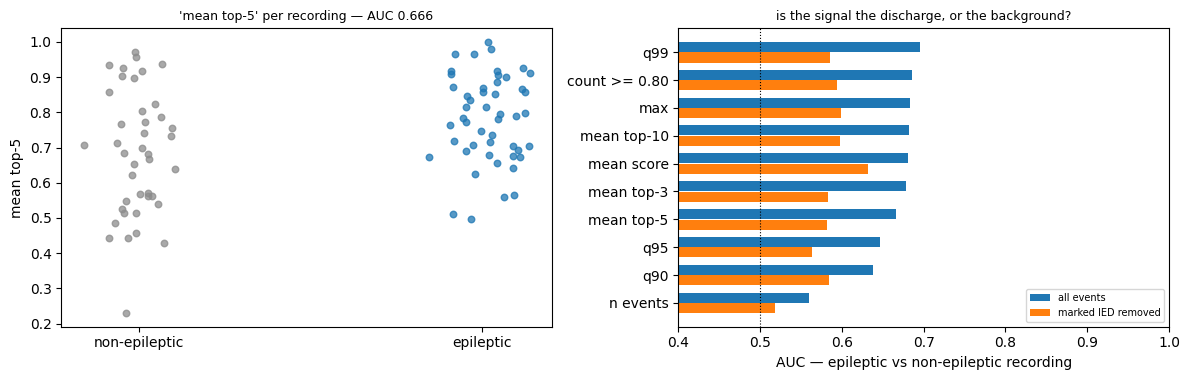

In [15]:
# Pilot pre-test: recording-level separation, epileptic vs non-epileptic, from out-of-fold scores.
# Also the control — repeat with the MARKED IED removed from each epileptic recording. If the separation
# survives, it is driven by epileptic background being more IED-like, not by the annotated discharge.
PRIMARY = 'mean top-5'      # pre-registered on transfer grounds, not argmax (see the markdown above)

if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.metrics import roc_auc_score

    thr = M.threshold_at(M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg), M.FP_BUDGET)
    tol, n = cfg.samp(cfg.hit_tol_ms), len(train)
    y = np.array([int(bool(train[g]['epi'])) for g in range(n)])

    def rec_scores(drop_marker):
        """Per-recording score lists, best first; optionally dropping near-marker events."""
        by = {}
        for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
            r = train[g]
            if drop_marker and r['epi'] and abs(e['time'] - r['mk']) <= tol:
                continue
            by.setdefault(int(g), []).append(s)
        return {g: np.sort(np.asarray(v))[::-1] for g, v in by.items()}

    def table(top):
        per = lambda f: np.array([float(f(top.get(g, np.zeros(1)))) for g in range(n)])
        return {f'count >= {thr:.2f}': per(lambda s: (s >= thr).sum()),
                'max': per(lambda s: s[0]),
                'mean top-3': per(lambda s: s[:3].mean()),
                'mean top-5': per(lambda s: s[:5].mean()),
                'mean top-10': per(lambda s: s[:10].mean()),
                'q99': per(lambda s: np.quantile(s, 0.99)),
                'q95': per(lambda s: np.quantile(s, 0.95)),
                'q90': per(lambda s: np.quantile(s, 0.90)),
                'mean score': per(lambda s: s.mean()),
                'n events': per(len)}

    stats, stats_x = table(rec_scores(False)), table(rec_scores(True))
    rows = []
    for name, v in stats.items():
        lo, hi = M.bootstrap_auc_ci(y, np.arange(n), v)     # each recording is its own bootstrap unit
        rows.append((roc_auc_score(y, v), lo, hi, roc_auc_score(y, stats_x[name]), name))
    rows.sort(reverse=True)

    print(f"recording-level separation from out-of-fold scores: "
          f"{y.sum()} epileptic vs {n - y.sum()} non-epileptic\n")
    print(f"{'statistic':<16} {'AUC':>6}   {'95% CI':<18} {'IED removed':>11} {'delta':>7}")
    for auc, lo, hi, aucx, name in rows:
        star = ' <- pre-registered' if name == PRIMARY else ''
        print(f"{name:<16} {auc:>6.3f}   [{lo:.3f}, {hi:.3f}]   {aucx:>11.3f} {aucx - auc:>+7.3f}{star}")

    p = next(r for r in rows if r[4] == PRIMARY)
    print(f"\nPRIMARY '{PRIMARY}': AUC {p[0]:.3f} [{p[1]:.3f}, {p[2]:.3f}], threshold {thr:.3f}")
    verdict = ('separation SURVIVES -> driven by epileptic background, not the annotated discharge'
               if p[3] > 0.65 else
               'separation COLLAPSES -> driven by the annotated discharges themselves')
    print(f"CONTROL  with the marked IED removed: {p[3]:.3f}  ({verdict})")

    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    rng = np.random.default_rng(0)
    for sel, col, lbl in ((0, '0.55', 'non-epileptic'), (1, 'C0', 'epileptic')):
        v = stats[PRIMARY][y == sel]
        axs[0].scatter(rng.normal(sel, 0.07, len(v)), v, s=22, alpha=0.75, color=col, label=lbl)
    axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(['non-epileptic', 'epileptic'])
    axs[0].set_ylabel(PRIMARY)
    axs[0].set_title(f"'{PRIMARY}' per recording — AUC {p[0]:.3f}", fontsize=9)

    names = [r[4] for r in rows][::-1]
    pos = np.arange(len(names))
    axs[1].barh(pos + 0.19, [r[0] for r in rows][::-1], height=0.36, color='C0', label='all events')
    axs[1].barh(pos - 0.19, [r[3] for r in rows][::-1], height=0.36, color='C1',
                label='marked IED removed')
    axs[1].set_yticks(pos); axs[1].set_yticklabels(names)
    axs[1].axvline(0.5, color='k', ls=':', lw=0.8)
    axs[1].set_xlim(0.4, 1.0); axs[1].set_xlabel('AUC — epileptic vs non-epileptic recording')
    axs[1].set_title('is the signal the discharge, or the background?', fontsize=9)
    axs[1].legend(fontsize=7, loc='lower right')
    plt.tight_layout()
    plt.savefig('../figures/detection_pilot_pretest.png', dpi=800, bbox_inches='tight')
    plt.show()


### Amplitude confound check

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

A substantial part of the recording-level separation survives removing the marked IED, so it is *not* the
annotated discharge. One explanation would not transfer to any other dataset: **the two groups may simply
differ in signal scale.**

The mechanism is specific. L1 divides its sharpness statistic by each channel's MAD, so it is
**scale-blind** — that is why `n events` sits at chance. L3 has no such normalisation: its windows are raw
µV, and the smoothing, registration and FPCA all operate on µV values (the StandardScaler standardises
component scores across the whole training set, not per recording). So a systematically larger recording
yields systematically larger FPCA scores and shifts along the discriminant, *without anything in it being
more IED-like*. Identical candidate counts, separating L3 scores, effect surviving marker removal — that is
exactly the pattern observed.

Two numbers settle it: whether background amplitude **alone** separates the groups, and whether it tracks
the per-recording statistic. The scatter is the real answer — if the groups separate vertically at a fixed
amplitude, the signal is not scale.

background amplitude (uV), median over recordings:
   epileptic        6.26
   non-epileptic    4.46

1) amplitude ALONE as a discriminator : AUC 0.759  95% CI [0.655, 0.847]
2) Spearman corr(amplitude, mean top-5)  : +0.060

-> CONFOUND IS LIVE: scale explains a substantial part of the separation.
   Per-recording amplitude normalisation before L3 is the fix to test.
   Read the scatter: if the two colours separate vertically at a fixed x, it is not scale.


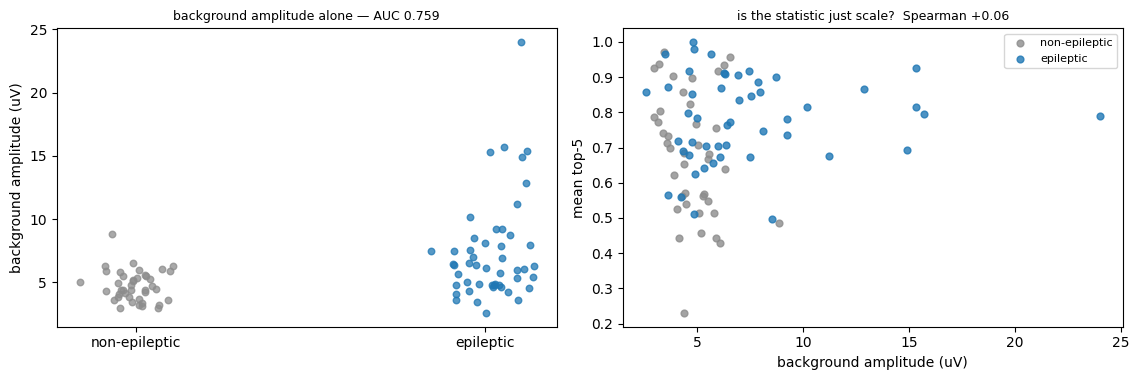

In [16]:
# Is the recording-level separation just signal scale?  (background amplitude = per-channel MAD of the
# raw uV signal, median across the 19 channels; MAD is robust, so one spike does not move it)
if 'stats' not in globals():
    print('Run the pilot pre-test cell above first.')
else:
    from scipy.stats import median_abs_deviation, spearmanr
    from sklearn.metrics import roc_auc_score

    bg = np.array([float(np.median(median_abs_deviation(r['X'], axis=1))) for r in train])
    auc_bg = roc_auc_score(y, bg)
    lo, hi = M.bootstrap_auc_ci(y, np.arange(n), bg)
    rho = spearmanr(bg, stats[PRIMARY])[0]

    print('background amplitude (uV), median over recordings:')
    print(f"   epileptic      {np.median(bg[y == 1]):6.2f}")
    print(f"   non-epileptic  {np.median(bg[y == 0]):6.2f}")
    print(f"\n1) amplitude ALONE as a discriminator : AUC {auc_bg:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
    print(f"2) Spearman corr(amplitude, {PRIMARY})  : {rho:+.3f}")
    # The verdict must key on rho, NOT on auc_bg. auc_bg only says amplitude separates the GROUPS; the
    # confound is that OUR STATISTIC is tracking amplitude, which is what rho measures. Keying on auc_bg
    # printed "CONFOUND IS LIVE" on 2026-08-18 when rho had already collapsed 0.708 -> 0.060 — i.e. it
    # announced a confound at the exact moment amplitude normalisation had removed it.
    if abs(rho) > 0.5:
        print('\n-> CONFOUND IS LIVE: the statistic tracks recording scale (see rho above).')
        print('   Per-recording amplitude normalisation before L3 is the fix to test.')
    else:
        print('\n-> confound is BROKEN: the statistic is decoupled from scale, so the separation it')
        print('   measures is not loudness. NOTE this is separate from whether amplitude *alone* also')
        print('   separates the groups (auc_bg above) — if it does, report it as its own baseline,')
        print('   because a one-line measure beating the model is a finding the pilot has to disclose.')
    print('   Read the scatter: if the two colours separate vertically at a fixed x, it is not scale.')

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.9))
    rng = np.random.default_rng(0)
    for sel, col, lbl in ((0, '0.55', 'non-epileptic'), (1, 'C0', 'epileptic')):
        axs[0].scatter(rng.normal(sel, 0.07, (y == sel).sum()), bg[y == sel], s=22, alpha=0.75,
                       color=col, label=lbl)
        axs[1].scatter(bg[y == sel], stats[PRIMARY][y == sel], s=24, alpha=0.8, color=col, label=lbl)
    axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(['non-epileptic', 'epileptic'])
    axs[0].set_ylabel('background amplitude (uV)')
    axs[0].set_title(f'background amplitude alone — AUC {auc_bg:.3f}', fontsize=9)
    axs[1].set_xlabel('background amplitude (uV)'); axs[1].set_ylabel(PRIMARY)
    axs[1].set_title(f'is the statistic just scale?  Spearman {rho:+.2f}', fontsize=9)
    axs[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('../figures/detection_amplitude_confound.png', dpi=800, bbox_inches='tight')
    plt.show()


### Error analysis, Phase 2 — look at the failures

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Phase 1 establishes two things that make this the next step. The missed IEDs cost a large median number of
extra false positives each to catch, and that number **did not move** when amplitude normalisation fixed
the cross-recording unfairness — so they are outranked by many events on a level playing field. That is a
morphology failure, not a calibration one, and no threshold change reaches it. Meanwhile a residual
false-positive asymmetry between epileptic and non-epileptic recordings survives normalisation, so it is
no longer scale.

Both questions are answered by looking rather than by measuring:

- **Top false positives.** Muscle burst, eye blink, sharp alpha, electrode pop — or a genuine-looking
  discharge that was never marked? If many are the last, the ceiling is the **label set**, not the model,
  and the "exactly one IED per recording" assumption the whole FROC rests on needs re-examining.
- **Missed IEDs.** What does a discharge look like when L3 confidently ranks it below hundreds of mimics?
  Low amplitude relative to its own background, unusual morphology, buried in artifact — or indistinguishable
  to the eye, in which case the ceiling is the feature space and L4 is the honest next move.

Representative channel in blue, the event's other member channels in grey, red dashed line at the event
centre. Raw µV, so panels are comparable within a recording but not across them.

181 false positives above 0.800; showing the top 12
15 missed IEDs; showing all, highest-scoring (closest to being caught) first


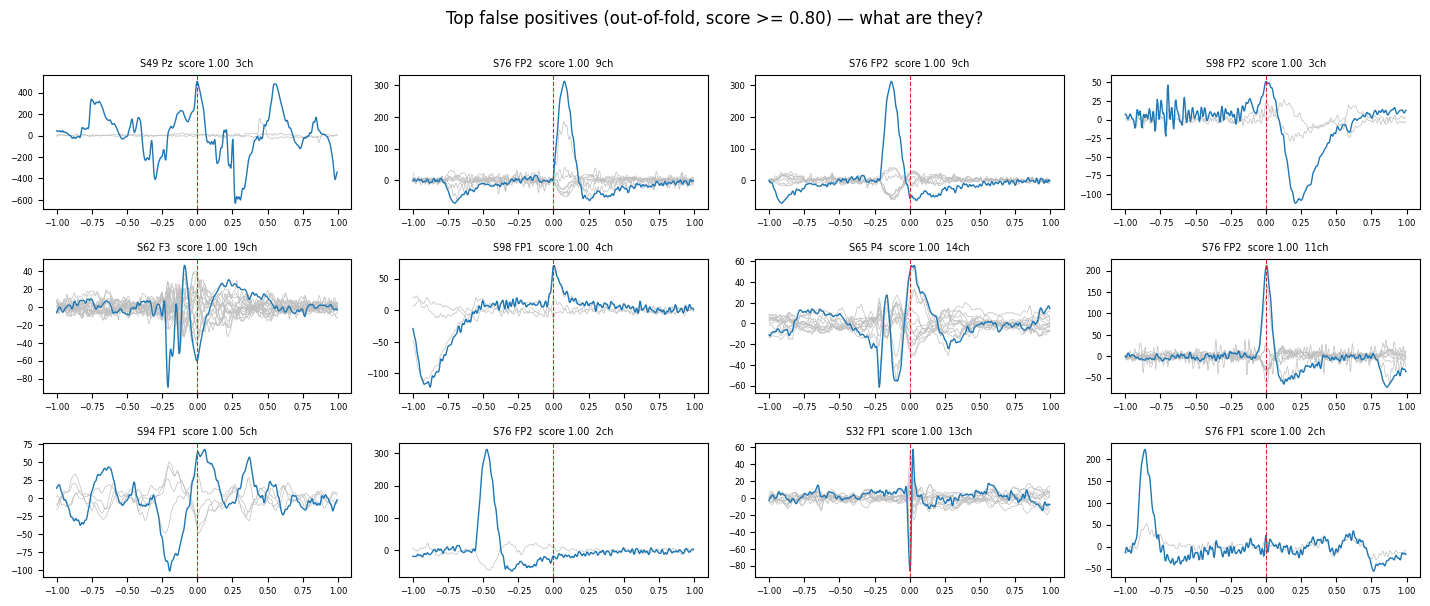

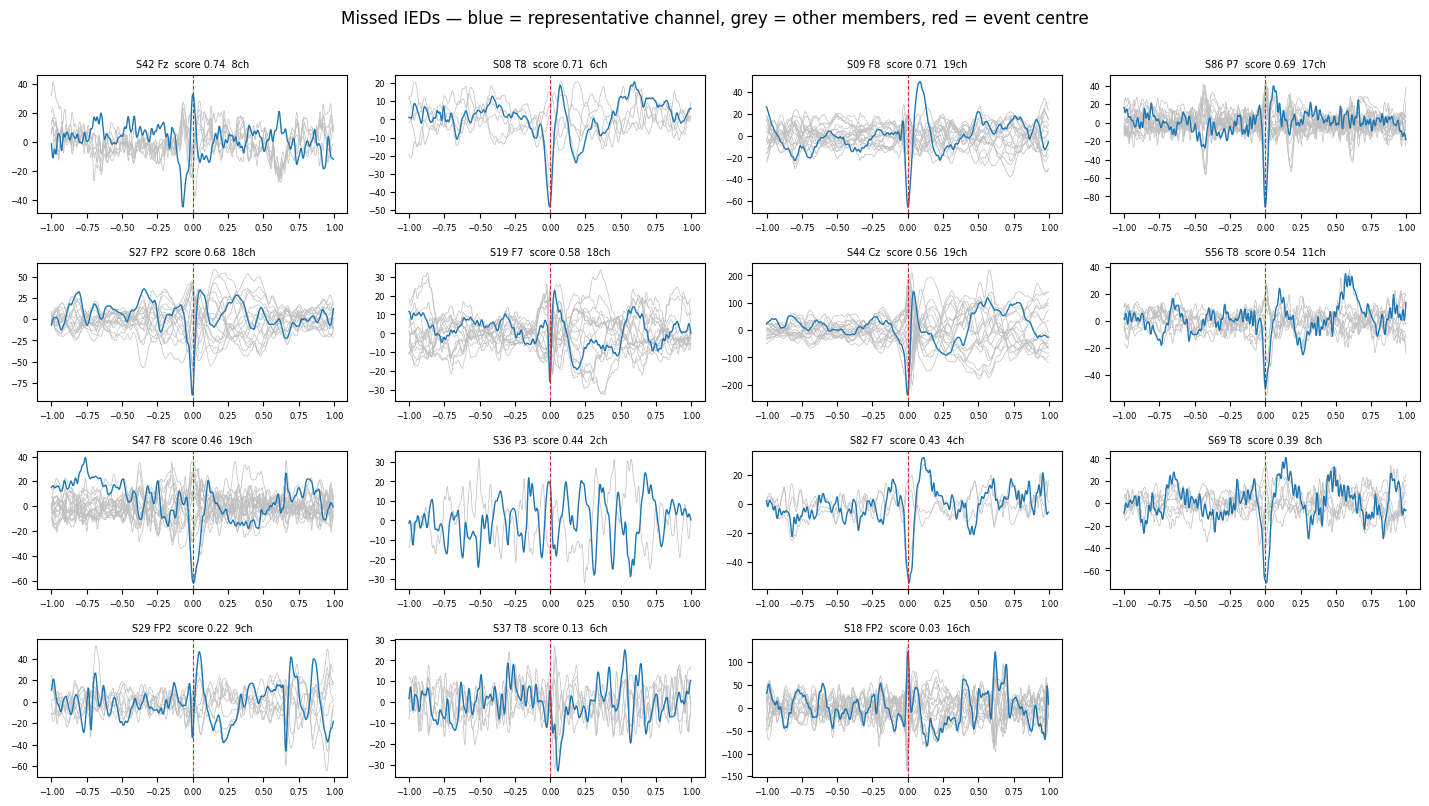

In [17]:
# Phase 2 — plot the failures. Top false positives, then every missed IED, worst-first by score.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from detect_data import CH19

    N_FP = 12
    tol = cfg.samp(cfg.hit_tol_ms)
    thr = M.threshold_at(M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg), M.FP_BUDGET)

    fps, best = [], {}
    for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
        r = train[g]
        if r['epi'] and abs(e['time'] - r['mk']) <= tol:
            if s > best.get(g, (-1.0, None))[0]:
                best[g] = (float(s), e)
        elif s >= thr:
            fps.append((float(s), g, e))
    fps.sort(key=lambda t: -t[0])
    misses = sorted(((s, g, e) for g, (s, e) in best.items() if s < thr), key=lambda t: -t[0])

    def grid(items, fname, suptitle):
        ncol = 4
        nrow = int(np.ceil(len(items) / ncol))
        fig, axs = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 2.0 * nrow), squeeze=False)
        for ax in axs.ravel()[len(items):]:
            ax.axis('off')
        for ax, (s, g, e) in zip(axs.ravel(), items):
            r = train[g]
            ch = CH19[e['channel']].replace('E ', '').replace('-Ref', '')
            P.event_panel(ax, r['X'], e, cfg,
                          f"{r['fid']} {ch}  score {s:.2f}  {e['n_channels']}ch")
        plt.suptitle(suptitle, y=1.002)
        plt.tight_layout()
        plt.savefig(fname, dpi=800, bbox_inches='tight')
        plt.show()

    print(f"{len(fps)} false positives above {thr:.3f}; showing the top {min(N_FP, len(fps))}")
    print(f"{len(misses)} missed IEDs; showing all, highest-scoring (closest to being caught) first")
    grid(fps[:N_FP], '../figures/detection_phase2_false_positives.png',
         f'Top false positives (out-of-fold, score >= {thr:.2f}) — what are they?')
    grid(misses, '../figures/detection_phase2_missed_ieds.png',
         'Missed IEDs — blue = representative channel, grey = other members, red = event centre')


In [18]:
def polarity(w):
    c = len(w) // 2
    return float(np.sign(w[c - 10:c + 10].mean() - np.median(w)))

from detection import event_window, _smooth
for lbl, items in (('hits', [(s, g, e) for g, (s, e) in best.items() if s >= thr]),
                   ('misses', misses), ('top FPs', fps[:30])):
    p = [polarity(event_window(train[g]['X'], e, cfg, _smooth(train[g]['X'], cfg)))
         for _, g, e in items]
    print(f"{lbl:<8} n={len(p):3d}  downward {np.mean(np.array(p) < 0):.0%}")


hits     n= 33  downward 82%
misses   n= 15  downward 73%
top FPs  n= 30  downward 60%


### Polarity as an explicit L3 feature

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Phase 2 measured that **polarity is a real IED cue that L3 was not using**: IEDs are predominantly
downward while L3's top-scoring false positives were close to a coin flip. L1 (|SG 2nd derivative|) and
L2 (|correlation|) are polarity-blind *by design* — the latter specifically so a dipole's reversed far side
still groups — and L3, the one layer that could use sign, evidently didn't: with ~60 positives and 24
components the LR may lack the data to isolate a direction encoding it.

So hand it over directly. `Classifier._polarity` takes the sign of the central deflection **from the window
itself** (mean over ±`cfg.polarity_ms` minus the window median) and `_features` appends it to the FPCA
scores before the scaler — one extra column, no signature changes anywhere, and scale-free, so
`normalise_amplitude` cannot touch it. Enabled by `cfg.polarity_feature`.

**Not** the obvious alternative: flipping windows to a common polarity would make L3 consistent with
L1/L2 and would **destroy** the cue just identified. And the polarity-*split* hypothesis was already
tested and refuted (hits 71% vs misses 81% is inside noise), so this is not expected to recover the misses.

The column sits **after** registration and FPCA, so both variants share one registration per fold — one CV
run, and the comparison is paired on identical folds with only the LR's feature matrix differing. Judged
the same way as centring and mining: the FROC's low-FP end and PR-AUC, with a paired recording-level
bootstrap of the difference. Expect a modest effect — as a lone binary feature the likelihood ratio is
~1.9 for downward and ~0.42 for upward.

In [19]:
# polarity-feature test. The column sits AFTER registration + FPCA, so both variants share one CV
# run — same trick as the n_components and mining sweeps, and here it also makes the comparison paired.
polarity_sweep = False

if polarity_sweep:
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    VARIANTS = ('base', 'polarity')
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    sc = {v: np.zeros(len(Y)) for v in VARIANTS}
    coefs = []

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=cfg.n_components).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        feats = {'base': (P_tr, P_te),
                 'polarity': (np.c_[P_tr, clf._polarity(W[tr])], np.c_[P_te, clf._polarity(W[te])])}
        for v in VARIANTS:
            A, B = feats[v]
            s = StandardScaler().fit(A)
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(s.transform(A), Y[tr])
            sc[v][te] = lr.predict_proba(s.transform(B))[:, 1]
            if v == 'polarity':
                coefs.append(lr.coef_[0])
        print(f'fold {f} done', flush=True)

    print(f"\n{'variant':>9} {'ROC-AUC':>8} {'PR-AUC':>7} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
          f"{'@50':>5} {'@100':>5}   hits/misses/FP @ <= {M.FP_BUDGET:.0f} FP/min")
    for v in VARIANTS:
        pts = M.froc_points(train, E, G, sc[v], cfg)
        fs = M.froc_summary(pts)
        c = M.detection_counts(train, E, G, sc[v], cfg, M.threshold_at(pts, M.FP_BUDGET))
        print(f"{v:>9} {roc_auc_score(Y, sc[v]):>8.3f} {average_precision_score(Y, sc[v]):>7.3f} "
              + ' '.join(f'{fs[t]:>5.2f}' for t in (1, 5, 10, 25, 50, 100))
              + f"   {c['hit']:>3} / {c['miss']:>3} / {c['fp']:>4}")
    print(f"(PR-AUC chance = {Y.mean():.4f})")

    # paired recording-level bootstrap of the difference — the same test the mining decision used
    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    d_pr, d_roc = [], []
    for _ in range(2000):
        take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
        if len(set(Y[take].tolist())) > 1:
            d_pr.append(average_precision_score(Y[take], sc['polarity'][take])
                        - average_precision_score(Y[take], sc['base'][take]))
            d_roc.append(roc_auc_score(Y[take], sc['polarity'][take])
                         - roc_auc_score(Y[take], sc['base'][take]))
    for name, d in (('PR-AUC', np.array(d_pr)), ('ROC-AUC', np.array(d_roc))):
        print(f"delta {name:>7} (polarity - base): {d.mean():+.4f}  95% CI "
              f"[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  P(>0)={np.mean(d > 0):.2f}")

    # did the LR actually use the column? (last coefficient, on standardised features)
    Cf = np.array(coefs)
    rank = [int((np.abs(c) > abs(c[-1])).sum()) + 1 for c in Cf]
    print(f"\npolarity coefficient per fold: {' · '.join(f'{c[-1]:+.3f}' for c in Cf)}")
    print(f"  |coef| rank among {Cf.shape[1]} features: {rank}  (1 = largest); "
          f"mean |coef| of the FPCA columns {np.abs(Cf[:, :-1]).mean():.3f}")
    print('  negative coefficient = downward windows score higher, the expected direction')

### `polarity_ms` — a robustness check, deliberately not a selection

`polarity_ms` is the half-width of the central stretch the sign is read from — a 40 ms average sitting on
the spike peak, compared against the window median. In samples that depends on the rate: ±10 at 500 Hz
(where the sweep below was run), ±5 at the current 250 Hz. The plateau result covers both, which is
precisely why the value is specified in ms.

**Pre-committed before running: `polarity_ms` stays at 20 whatever this returns.** 20 ms is the value the
Phase-2 measurement used, so the feature measures exactly the thing that motivated building it, and it is
also the defensible choice on signal-processing grounds — an IED spike is 20–70 ms wide, so 40 ms sits
inside the spike, while a few samples would be noise-dominated. Picking a width off this table would be
tuning a knob on an effect whose confidence interval already touches zero, over 49 IEDs. The question here
is **whether the polarity result depends on the choice**, not which choice scores best.

**Pre-registered prediction: wide widths should degrade.** The after-going slow wave has the opposite
polarity to the spike, so a wide central average mixes the two and mismeasures the sign. The
`downward over positives` column tests that directly, before any model is involved — if it drifts toward
50% as the width grows, the sign measurement itself is breaking down.

How to read the result: a flat curve means the feature is robust; a large spread means the effect hinges on
a 10 ms implementation detail and is probably noise. Neither outcome changes the value of `polarity_ms`.

In [20]:
# polarity_ms ROBUSTNESS sweep (not a selection — 20 ms stays, see the markdown above).
# Polarity is computed from the raw window, so it sits downstream of registration: every width shares one
# CV run, like the n_components sweep.
polarity_ms_sweep = False

if polarity_ms_sweep:
    from dataclasses import replace
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    MS = [4.0, 10.0, 20.0, 40.0, 80.0]        # 20 = pre-specified; 80 should start eating the slow wave
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)

    # the sign measurement itself, before any model
    pol = {v: Classifier(replace(cfg, polarity_ms=v))._polarity(W) for v in MS}
    print(f"{'ms':>5} {'samples':>8} {'downward: all':>14} {'positives':>10}   agreement with 20 ms")
    for v in MS:
        print(f"{v:>5.0f} {cfg.samp(v) * 2:>8} {np.mean(pol[v] < 0):>13.0%} "
              f"{np.mean(pol[v][Y == 1] < 0):>10.0%}   {np.mean(pol[v] == pol[20.0]):>6.0%}")

    ARMS = ['base'] + MS
    sc = {a: np.zeros(len(Y)) for a in ARMS}
    coefs = {v: [] for v in MS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=cfg.n_components).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        for a in ARMS:
            A, B = ((P_tr, P_te) if a == 'base'
                    else (np.c_[P_tr, pol[a][tr]], np.c_[P_te, pol[a][te]]))
            s = StandardScaler().fit(A)
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(s.transform(A), Y[tr])
            sc[a][te] = lr.predict_proba(s.transform(B))[:, 1]
            if a != 'base':
                coefs[a].append(lr.coef_[0][-1])
        print(f'fold {f} done', flush=True)

    print(f"\n{'arm':>8} {'ROC-AUC':>8} {'PR-AUC':>7} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
          f"{'@50':>5} {'@100':>5}   hits/miss/FP @<={M.FP_BUDGET:.0f}   coef")
    for a in ARMS:
        pts = M.froc_points(train, E, G, sc[a], cfg)
        fs = M.froc_summary(pts)
        c = M.detection_counts(train, E, G, sc[a], cfg, M.threshold_at(pts, M.FP_BUDGET))
        tag = 'base' if a == 'base' else f'{a:.0f} ms'
        coef = '' if a == 'base' else f"{np.mean(coefs[a]):+.3f}"
        star = '  <- pre-specified' if a == 20.0 else ''
        print(f"{tag:>8} {roc_auc_score(Y, sc[a]):>8.3f} {average_precision_score(Y, sc[a]):>7.3f} "
              + ' '.join(f'{fs[t]:>5.2f}' for t in (1, 5, 10, 25, 50, 100))
              + f"   {c['hit']:>3} /{c['miss']:>3} /{c['fp']:>4}   {coef:>7}{star}")

    prs = [average_precision_score(Y, sc[v]) for v in MS]
    print(f"\nPR-AUC across widths: {min(prs):.3f}-{max(prs):.3f} "
          f"(spread {max(prs) - min(prs):.3f}), base {average_precision_score(Y, sc['base']):.3f}")